# Part 4: NAS 종합 분석

## 이 노트북에서 다루는 내용
1. Baseline vs Random Search vs Evolutionary Search 종합 비교
2. 전체 탐색 결과 시각화
3. 탐색 효율 비교
4. 아키텍처 패턴 분석

**참고**: Part 2, 3 노트북의 결과를 활용합니다. 이전 노트북을 먼저 실행해야 합니다.

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import time
import json
import random
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    CNN, FlexibleCNN, SEARCH_SPACE,
    sample_architecture, architecture_to_string, mutate_architecture
)

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_CLASSES = 10
SEARCH_EPOCHS = 5
FULL_EPOCHS = 10
NUM_SAMPLES = 20
POPULATION_SIZE = 10
NUM_GENERATIONS = 5
TOURNAMENT_SIZE = 3
ELITE_SIZE = 2

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습/평가 함수 정의

In [3]:
def train(model, train_loader, epochs, learning_rate, device, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()
    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        if verbose:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")
    return epoch_losses

def test(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def train_and_evaluate(arch, train_loader, test_loader, epochs, learning_rate, device, seed=42):
    torch.manual_seed(seed)
    model = FlexibleCNN(arch, num_classes=NUM_CLASSES)
    params = count_parameters(model)
    start_time = time.time()
    train_losses = train(model, train_loader, epochs, learning_rate, device, verbose=False)
    train_time = time.time() - start_time
    accuracy = test(model, test_loader, device)
    return {'arch': arch, 'accuracy': accuracy, 'params': params,
            'train_losses': train_losses, 'train_time': train_time}

## [3] 실험 수행

Baseline + Random Search + Evolutionary Search를 모두 실행합니다.

In [4]:
# Baseline
print("[Baseline]")
torch.manual_seed(SEED)
baseline_model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
baseline_params = count_parameters(baseline_model)
print(f"  파라미터: {baseline_params:,}")
train(baseline_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(baseline_model, test_loader, DEVICE)
print(f"  정확도: {baseline_accuracy:.2f}%")

[Baseline]
  파라미터: 1,186,986
Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347
  정확도: 75.01%


In [5]:
# Random Search
print(f"[Random Search] {NUM_SAMPLES}개 아키텍처")
random_results = []
for i in range(NUM_SAMPLES):
    arch = sample_architecture(seed=SEED + i)
    result = train_and_evaluate(
        arch, train_loader, test_loader,
        SEARCH_EPOCHS, LEARNING_RATE, DEVICE, seed=SEED
    )
    random_results.append(result)
    if (i + 1) % 5 == 0:
        print(f"  [{i+1}/{NUM_SAMPLES}] Best so far: {max(r['accuracy'] for r in random_results):.2f}%")

random_results.sort(key=lambda x: x['accuracy'], reverse=True)
random_best = random_results[0]
print(f"  Best: {architecture_to_string(random_best['arch'])} | Acc: {random_best['accuracy']:.2f}%")

# Best 전체 학습
torch.manual_seed(SEED)
rand_best_model = FlexibleCNN(random_best['arch'], num_classes=NUM_CLASSES)
train(rand_best_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE, verbose=False)
random_best_full_accuracy = test(rand_best_model, test_loader, DEVICE)
print(f"  전체 학습 정확도: {random_best_full_accuracy:.2f}%")

[Random Search] 20개 아키텍처
  [5/20] Best so far: 75.22%
  [10/20] Best so far: 75.61%
  [15/20] Best so far: 77.86%
  [20/20] Best so far: 77.86%
  Best: F[16-128-64-128]_K[3-3-5-3]_FC512 | Acc: 77.86%
  전체 학습 정확도: 79.35%


In [6]:
# Evolutionary Search
print(f"[Evolutionary Search] Pop={POPULATION_SIZE}, Gen={NUM_GENERATIONS}")
evo_all_evaluated = []
evo_generation_history = []

evo_population = []
evo_fitnesses = []

# 초기 인구
for i in range(POPULATION_SIZE):
    arch = sample_architecture(seed=SEED + i)
    result = train_and_evaluate(
        arch, train_loader, test_loader,
        SEARCH_EPOCHS, LEARNING_RATE, DEVICE, seed=SEED
    )
    evo_population.append(arch)
    evo_fitnesses.append(result['accuracy'])
    evo_all_evaluated.append(result)

best_idx = np.argmax(evo_fitnesses)
evo_generation_history.append({
    'generation': 0,
    'best_accuracy': evo_fitnesses[best_idx],
    'mean_accuracy': float(np.mean(evo_fitnesses)),
})
print(f"  세대 0 | Best: {evo_fitnesses[best_idx]:.2f}% | Mean: {np.mean(evo_fitnesses):.2f}%")

# 세대별 진화
for gen in range(1, NUM_GENERATIONS + 1):
    sorted_indices = sorted(range(len(evo_fitnesses)),
                             key=lambda i: evo_fitnesses[i], reverse=True)
    elite_indices = sorted_indices[:ELITE_SIZE]

    new_pop = [copy.deepcopy(evo_population[i]) for i in elite_indices]
    new_fit = [evo_fitnesses[i] for i in elite_indices]

    for _ in range(POPULATION_SIZE - ELITE_SIZE):
        indices = random.sample(range(len(evo_population)),
                                 min(TOURNAMENT_SIZE, len(evo_population)))
        parent_idx = max(indices, key=lambda i: evo_fitnesses[i])
        parent = copy.deepcopy(evo_population[parent_idx])
        child = mutate_architecture(parent)

        result = train_and_evaluate(
            child, train_loader, test_loader,
            SEARCH_EPOCHS, LEARNING_RATE, DEVICE, seed=SEED
        )
        new_pop.append(child)
        new_fit.append(result['accuracy'])
        evo_all_evaluated.append(result)

    evo_population = new_pop
    evo_fitnesses = new_fit

    best_idx = np.argmax(evo_fitnesses)
    evo_generation_history.append({
        'generation': gen,
        'best_accuracy': evo_fitnesses[best_idx],
        'mean_accuracy': float(np.mean(evo_fitnesses)),
    })
    print(f"  세대 {gen} | Best: {evo_fitnesses[best_idx]:.2f}% | "
          f"Mean: {np.mean(evo_fitnesses):.2f}% | 총 평가: {len(evo_all_evaluated)}개")

evo_best = max(evo_all_evaluated, key=lambda x: x['accuracy'])
print(f"\n  Best: {architecture_to_string(evo_best['arch'])} | Acc: {evo_best['accuracy']:.2f}%")

# Best 전체 학습
torch.manual_seed(SEED)
evo_best_model = FlexibleCNN(evo_best['arch'], num_classes=NUM_CLASSES)
train(evo_best_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE, verbose=False)
evo_best_full_accuracy = test(evo_best_model, test_loader, DEVICE)
print(f"  전체 학습 정확도: {evo_best_full_accuracy:.2f}%")

[Evolutionary Search] Pop=10, Gen=5
  세대 0 | Best: 75.61% | Mean: 74.19%
  세대 1 | Best: 76.06% | Mean: 74.72% | 총 평가: 18개
  세대 2 | Best: 76.25% | Mean: 75.19% | 총 평가: 26개
  세대 3 | Best: 78.08% | Mean: 76.01% | 총 평가: 34개
  세대 4 | Best: 78.52% | Mean: 76.41% | 총 평가: 42개
  세대 5 | Best: 78.80% | Mean: 76.66% | 총 평가: 50개

  Best: F[128-64-64-128]_K[3-3-5-5]_FC1024 | Acc: 78.80%
  전체 학습 정확도: 78.23%


## [4] 종합 비교 시각화

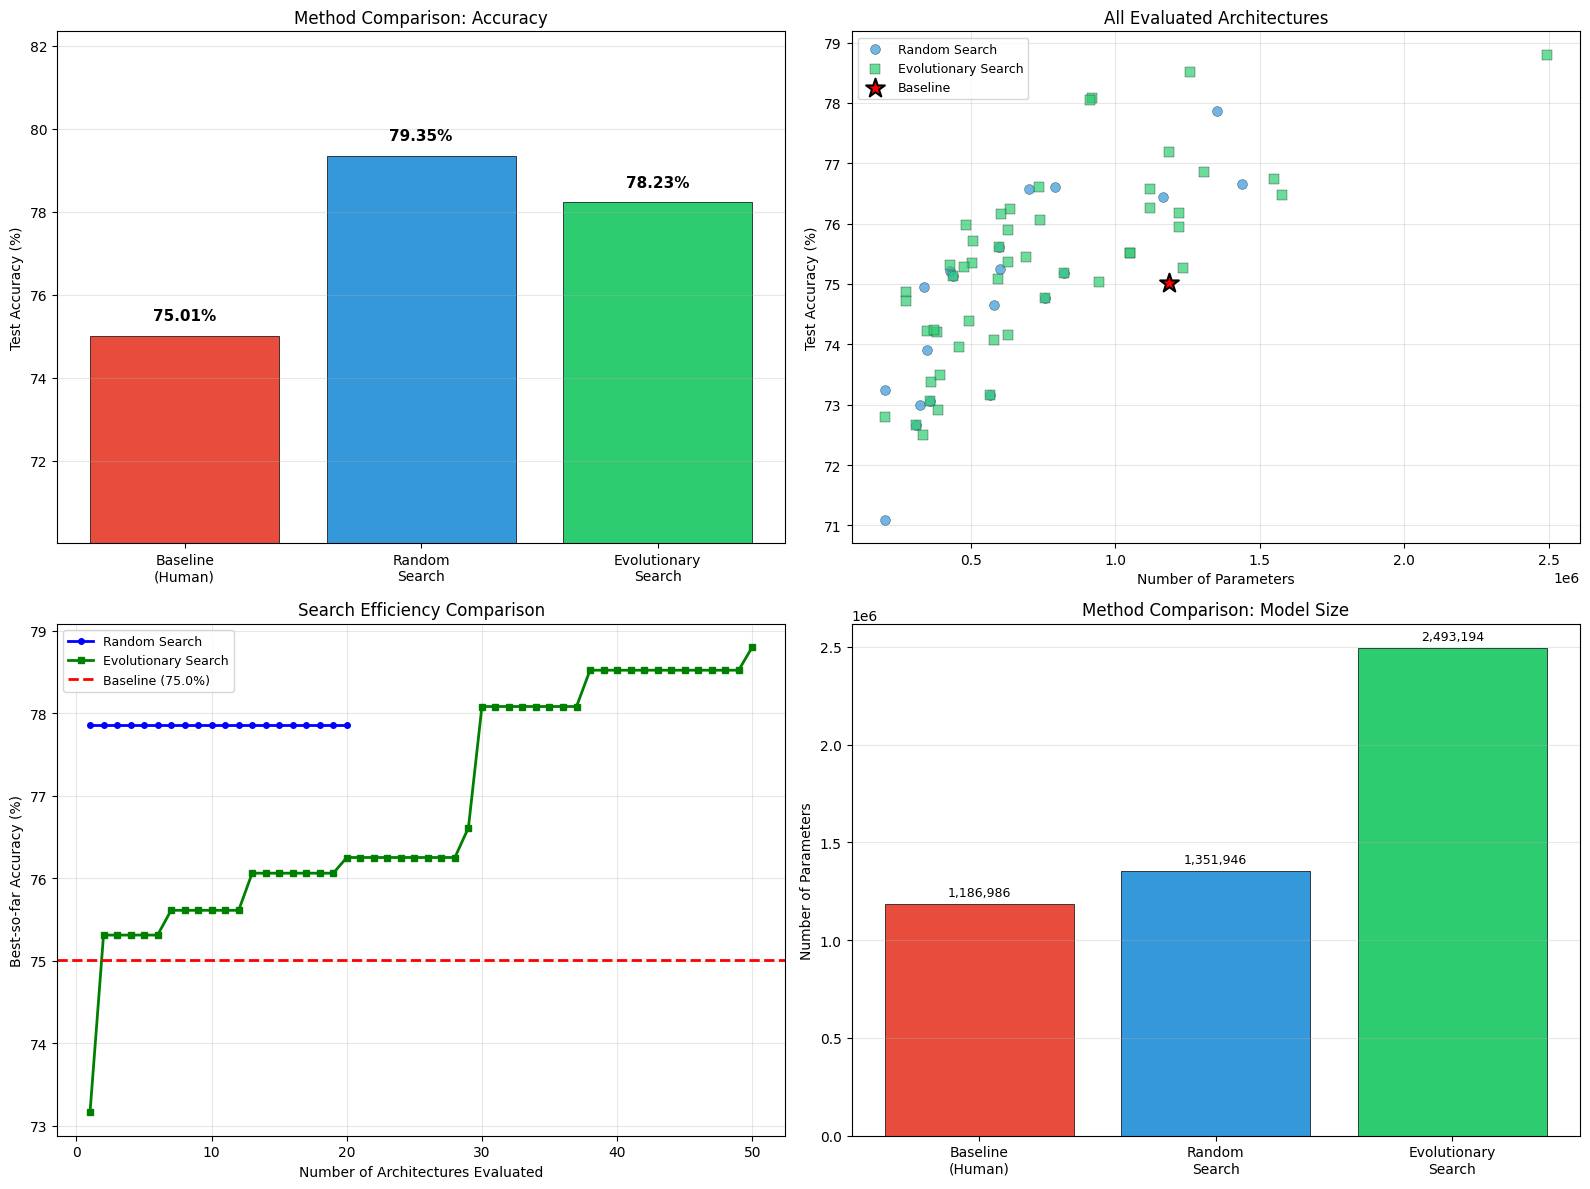

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: 방법별 정확도 비교 ---
ax1 = axes[0][0]
methods = ['Baseline\n(Human)', 'Random\nSearch', 'Evolutionary\nSearch']
accuracies = [baseline_accuracy, random_best_full_accuracy, evo_best_full_accuracy]
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax1.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Method Comparison: Accuracy')
ax1.set_ylim(min(accuracies) - 5, max(accuracies) + 3)
ax1.grid(True, alpha=0.3, axis='y')

# --- Plot 2: 전체 탐색 결과 scatter ---
ax2 = axes[0][1]
rand_accs = [r['accuracy'] for r in random_results]
rand_params = [r['params'] for r in random_results]
ax2.scatter(rand_params, rand_accs, c='#3498db', s=50, alpha=0.7,
            edgecolors='black', linewidth=0.3, label='Random Search', zorder=3)

evo_accs = [r['accuracy'] for r in evo_all_evaluated]
evo_params = [r['params'] for r in evo_all_evaluated]
ax2.scatter(evo_params, evo_accs, c='#2ecc71', s=50, alpha=0.7,
            edgecolors='black', linewidth=0.3, marker='s',
            label='Evolutionary Search', zorder=3)

ax2.scatter([baseline_params], [baseline_accuracy], c='red', s=200,
            marker='*', edgecolors='black', linewidth=1.5, zorder=4, label='Baseline')

ax2.set_xlabel('Number of Parameters')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('All Evaluated Architectures')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: 탐색 효율 비교 ---
ax3 = axes[1][0]

# Random Search best-so-far
rand_bsf = []
current_best = 0
for r in random_results:
    current_best = max(current_best, r['accuracy'])
    rand_bsf.append(current_best)
ax3.plot(range(1, len(rand_bsf) + 1), rand_bsf, 'b-o', markersize=4, linewidth=2, label='Random Search')

# Evolutionary best-so-far
evo_bsf = []
current_best = 0
for r in evo_all_evaluated:
    current_best = max(current_best, r['accuracy'])
    evo_bsf.append(current_best)
ax3.plot(range(1, len(evo_bsf) + 1), evo_bsf, 'g-s', markersize=4, linewidth=2, label='Evolutionary Search')

ax3.axhline(y=baseline_accuracy, color='red', linestyle='--', linewidth=2,
            label=f'Baseline ({baseline_accuracy:.1f}%)')
ax3.set_xlabel('Number of Architectures Evaluated')
ax3.set_ylabel('Best-so-far Accuracy (%)')
ax3.set_title('Search Efficiency Comparison')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Plot 4: 방법별 파라미터 수 비교 ---
ax4 = axes[1][1]
params_list = [baseline_params, random_best['params'], evo_best['params']]
bars = ax4.bar(methods, params_list, color=colors, edgecolor='black', linewidth=0.5)

for bar, p in zip(bars, params_list):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(params_list) * 0.01,
             f'{p:,}', ha='center', va='bottom', fontsize=9)

ax4.set_ylabel('Number of Parameters')
ax4.set_title('Method Comparison: Model Size')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## [5] 아키텍처 패턴 분석

In [8]:
# 모든 평가 결과 합치기
all_results = random_results + evo_all_evaluated
all_results.sort(key=lambda x: x['accuracy'], reverse=True)

n = len(all_results)
top_quarter = all_results[:n // 4]
bottom_quarter = all_results[-(n // 4):]

print(f"전체 평가된 아키텍처: {n}개")
print(f"Top 25%: {len(top_quarter)}개 (>= {top_quarter[-1]['accuracy']:.2f}%)")
print(f"Bottom 25%: {len(bottom_quarter)}개 (<= {bottom_quarter[0]['accuracy']:.2f}%)")

전체 평가된 아키텍처: 70개
Top 25%: 17개 (>= 76.25%)
Bottom 25%: 17개 (<= 74.07%)


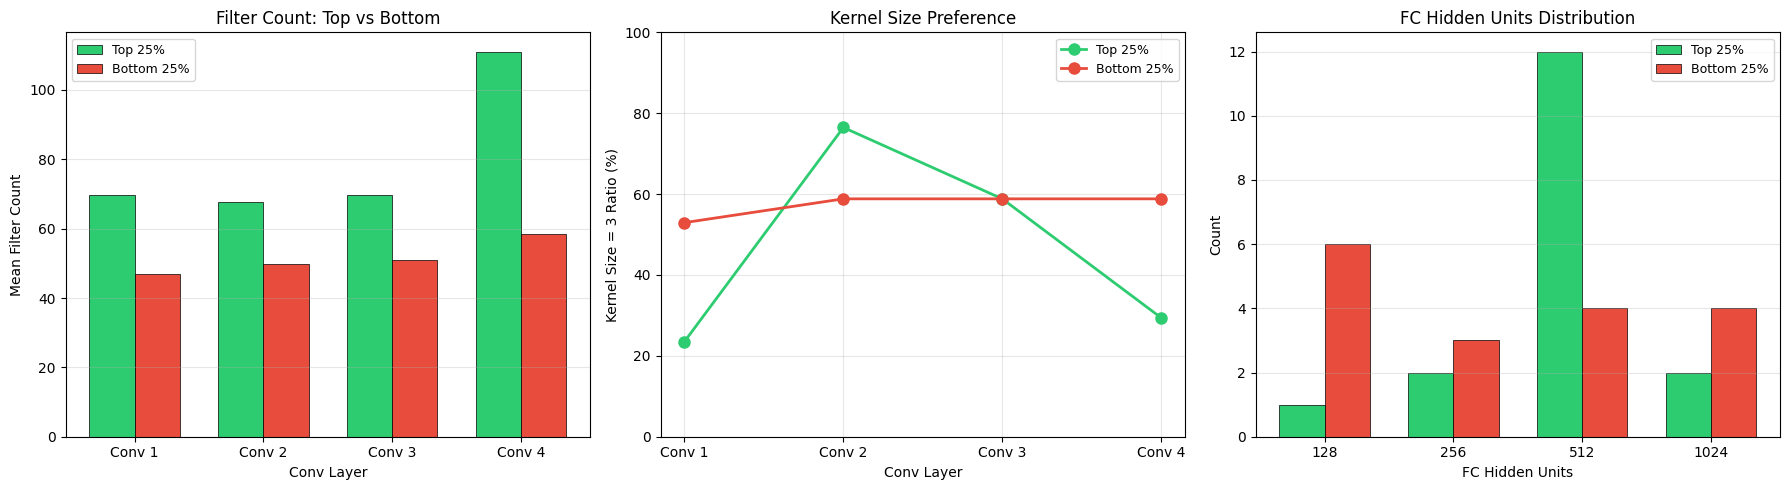

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

num_conv = SEARCH_SPACE['num_conv_layers']
width = 0.35

# --- Plot 1: 레이어별 필터 수 ---
ax1 = axes[0]
x_pos = np.arange(num_conv)

top_mean_filters = [np.mean([r['arch']['filters'][i] for r in top_quarter]) for i in range(num_conv)]
bottom_mean_filters = [np.mean([r['arch']['filters'][i] for r in bottom_quarter]) for i in range(num_conv)]

ax1.bar(x_pos - width/2, top_mean_filters, width, color='#2ecc71',
        edgecolor='black', linewidth=0.5, label=f'Top 25%')
ax1.bar(x_pos + width/2, bottom_mean_filters, width, color='#e74c3c',
        edgecolor='black', linewidth=0.5, label=f'Bottom 25%')

ax1.set_xlabel('Conv Layer')
ax1.set_ylabel('Mean Filter Count')
ax1.set_title('Filter Count: Top vs Bottom')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'Conv {i+1}' for i in range(num_conv)])
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# --- Plot 2: 커널 크기 선호도 ---
ax2 = axes[1]
for group, label, color in [(top_quarter, 'Top 25%', '#2ecc71'),
                              (bottom_quarter, 'Bottom 25%', '#e74c3c')]:
    k3_ratios = []
    for i in range(num_conv):
        k3_count = sum(1 for r in group if r['arch']['kernel_sizes'][i] == 3)
        k3_ratios.append(k3_count / len(group) * 100)
    ax2.plot(range(num_conv), k3_ratios, 'o-', color=color, markersize=8, linewidth=2, label=label)

ax2.set_xlabel('Conv Layer')
ax2.set_ylabel('Kernel Size = 3 Ratio (%)')
ax2.set_title('Kernel Size Preference')
ax2.set_xticks(range(num_conv))
ax2.set_xticklabels([f'Conv {i+1}' for i in range(num_conv)])
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: FC Hidden Units 분포 ---
ax3 = axes[2]
fc_options = SEARCH_SPACE['fc_hidden']

top_fc = [sum(1 for r in top_quarter if r['arch']['fc_hidden'] == fc) for fc in fc_options]
bottom_fc = [sum(1 for r in bottom_quarter if r['arch']['fc_hidden'] == fc) for fc in fc_options]

x_pos = np.arange(len(fc_options))
ax3.bar(x_pos - width/2, top_fc, width, color='#2ecc71',
        edgecolor='black', linewidth=0.5, label='Top 25%')
ax3.bar(x_pos + width/2, bottom_fc, width, color='#e74c3c',
        edgecolor='black', linewidth=0.5, label='Bottom 25%')

ax3.set_xlabel('FC Hidden Units')
ax3.set_ylabel('Count')
ax3.set_title('FC Hidden Units Distribution')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([str(fc) for fc in fc_options])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 종합 결과

In [10]:
print("=" * 70)
print("종합 결과 비교")
print("=" * 70)
print(f"\n{'Method':<25} {'Accuracy':<12} {'Params':<15} {'탐색 비용':<15}")
print("-" * 67)
print(f"{'Baseline (Human)':<25} {baseline_accuracy:>8.2f}% {baseline_params:>12,} {'N/A':>12}")
print(f"{'Random Search':<25} {random_best_full_accuracy:>8.2f}% {random_best['params']:>12,} {str(len(random_results))+'개':>12}")
print(f"{'Evolutionary Search':<25} {evo_best_full_accuracy:>8.2f}% {evo_best['params']:>12,} {str(len(evo_all_evaluated))+'개':>12}")
print("-" * 67)

print(f"\n[Best 아키텍처]")
print(f"  Random:       {architecture_to_string(random_best['arch'])}")
print(f"  Evolutionary: {architecture_to_string(evo_best['arch'])}")

print(f"\n[결론]")
print(f"  1. NAS는 사람이 설계한 Baseline과 비교하여 자동으로 아키텍처를 찾을 수 있습니다.")
print(f"  2. Random Search는 간단하지만 놀라울 정도로 효과적입니다.")
print(f"  3. Evolutionary Search는 좋은 아키텍처 '근처'를 집중 탐색합니다.")
print(f"  4. 탐색 공간 설계가 NAS 성능에 매우 중요합니다.")

종합 결과 비교

Method                    Accuracy     Params          탐색 비용          
-------------------------------------------------------------------
Baseline (Human)             75.01%    1,186,986          N/A
Random Search                79.35%    1,351,946          20개
Evolutionary Search          78.23%    2,493,194          50개
-------------------------------------------------------------------

[Best 아키텍처]
  Random:       F[16-128-64-128]_K[3-3-5-3]_FC512
  Evolutionary: F[128-64-64-128]_K[3-3-5-5]_FC1024

[결론]
  1. NAS는 사람이 설계한 Baseline과 비교하여 자동으로 아키텍처를 찾을 수 있습니다.
  2. Random Search는 간단하지만 놀라울 정도로 효과적입니다.
  3. Evolutionary Search는 좋은 아키텍처 '근처'를 집중 탐색합니다.
  4. 탐색 공간 설계가 NAS 성능에 매우 중요합니다.
